In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [112]:
df = pd.read_csv("data/telco_customer_churn.csv", encoding= 'unicode_escape')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [113]:
df.shape

(7043, 21)

In [114]:
df.info()
df.describe()
df['Churn'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [115]:
# use describe() for specific columns
df[['SeniorCitizen','tenure','MonthlyCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [116]:
pd.isnull(df).sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [117]:
# Exploratory Data Analysis

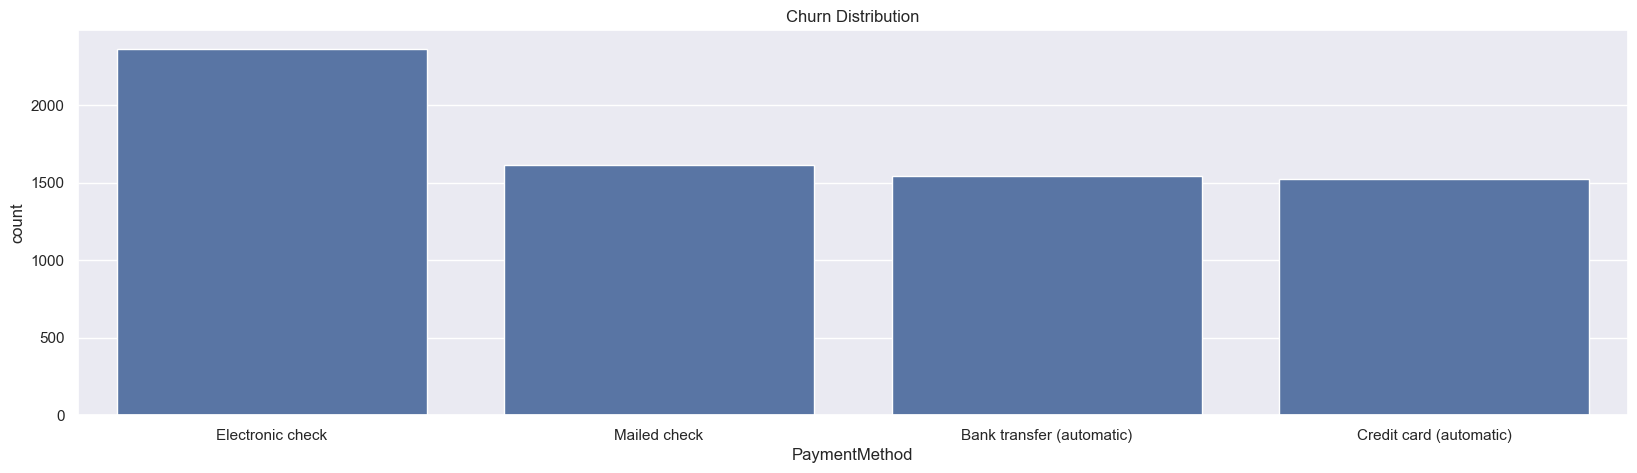

In [118]:
sns.countplot(x='PaymentMethod', data=df)
plt.title("Churn Distribution")
plt.show()


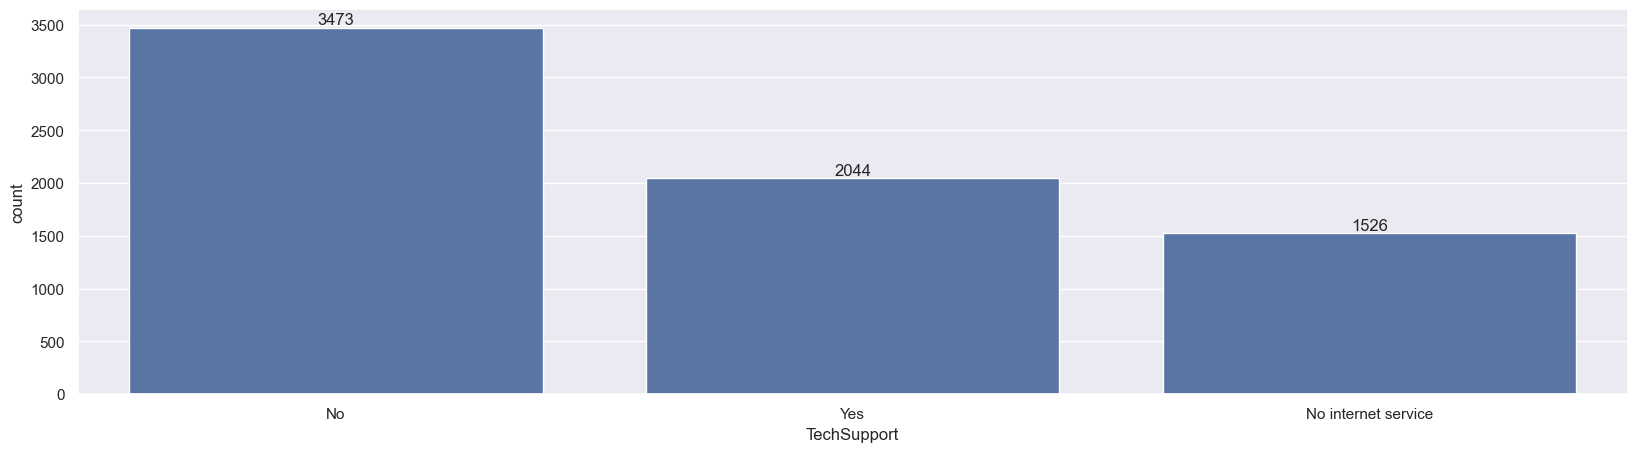

In [119]:
ax = sns.countplot(x = 'TechSupport',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

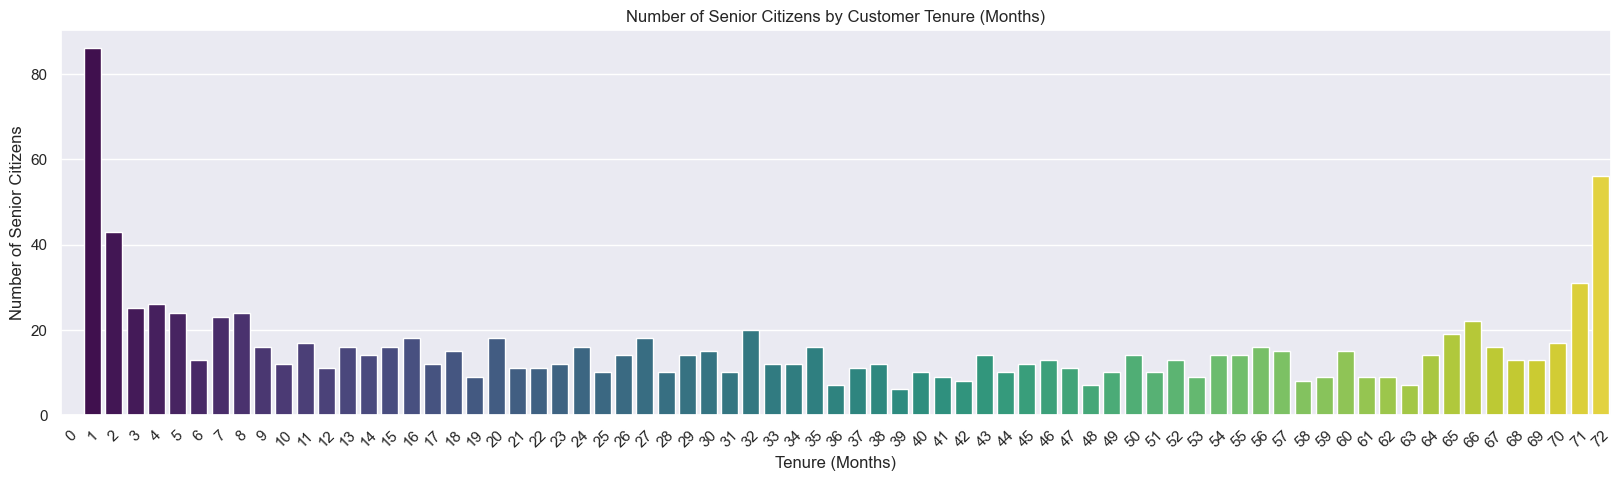

In [120]:
senior_counts_by_tenure = df.groupby('tenure', as_index=False)['SeniorCitizen'].sum()

# Sort by SeniorCitizen count descending (optional if you want to see highest counts first)
senior_counts_by_tenure = senior_counts_by_tenure.sort_values(by='SeniorCitizen', ascending=False, )

# Plot
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(x='tenure', y='SeniorCitizen', data=senior_counts_by_tenure, palette='viridis', hue='tenure', legend=False)

plt.title('Number of Senior Citizens by Customer Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Senior Citizens')
plt.xticks(rotation=45)
plt.show()





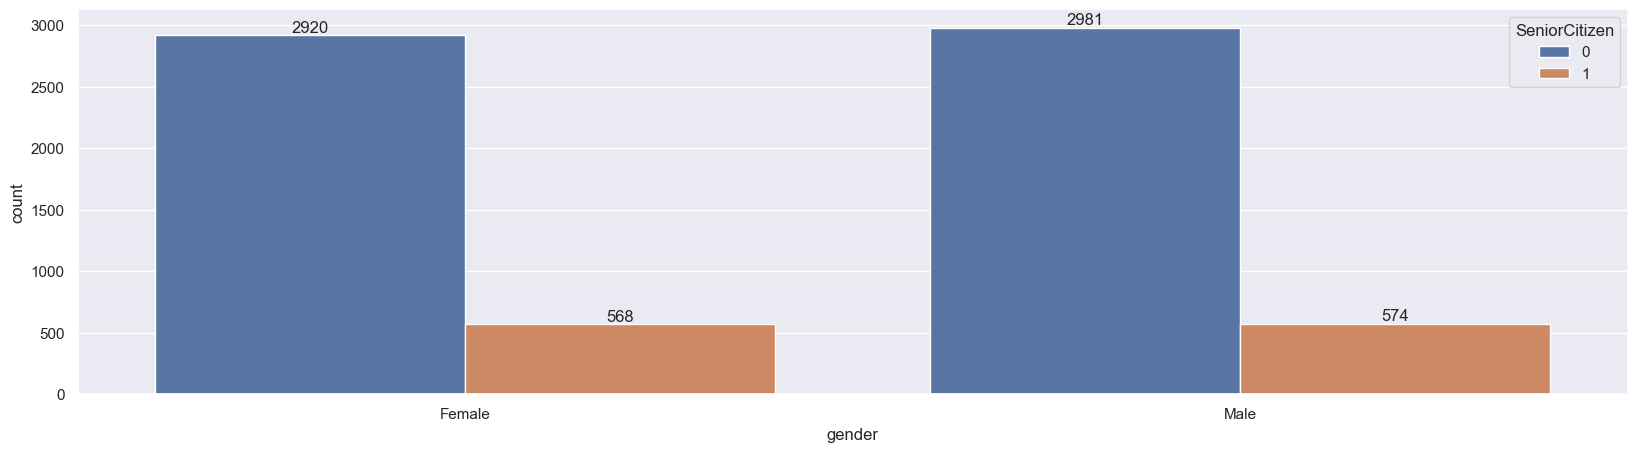

In [121]:
ax = sns.countplot(data = df, x = 'gender', hue = 'SeniorCitizen')

for bars in ax.containers:
    ax.bar_label(bars)

In [122]:
df = df.drop(['customerID'], axis=1)  
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)


for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])


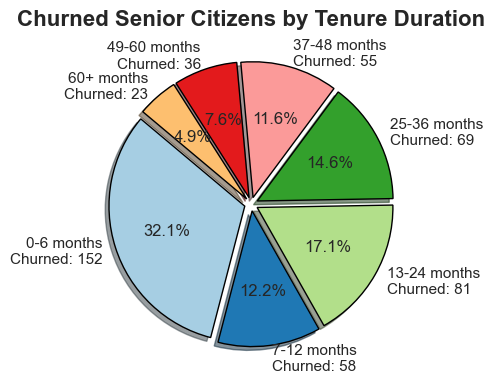

In [123]:
customer_id_col = 'customerID'

senior_df = df[df['SeniorCitizen'] == 1].copy()

bins = [0, 6, 12, 24, 36, 48, 60, senior_df['tenure'].max()]
labels = ['0-6 months', '7-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '60+ months']
senior_df['tenure_group'] = pd.cut(senior_df['tenure'], bins=bins, labels=labels, right=False)

senior_churn_by_group = senior_df.groupby('tenure_group', observed=True)['Churn'].sum()

custom_labels = [f"{label}\nChurned: {count}" for label, count in zip(labels, senior_churn_by_group)]

plt.figure(figsize=(5,5))
colors = plt.cm.Paired.colors

senior_churn_by_group.plot.pie(
    labels=custom_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    shadow=True,
    explode=[0.05]*len(senior_churn_by_group),
    wedgeprops={'edgecolor': 'black'},
    labeldistance=1.1
)

plt.title('Churned Senior Citizens by Tenure Duration', fontsize=16, weight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [124]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [125]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [126]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.790521327014218
Confusion Matrix:
 [[1397  152]
 [ 290  271]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110

